#**Taller 3: Costrucción de un Modelo que prediga el precio de las casas en Boston empleando Algoritnos de 1. Arbol de Decisión, 2. Random Forest, 3.  Gradien Boosting, 4. Extreme Gradien Boosting, 5. Light Gradien Boosting**

In [57]:
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1 - Cargar Librerias

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [59]:
from sklearn import datasets, linear_model

# 2 - Cargar los Datos

In [60]:
#Se usara un dataset disponible en gitbub
# https://raw.githubusercontent.com/selva86/datasets/refs/heads/master/BostonHousing.csv

# o la copia cargada en Github
# https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_03_Dataset_Boston_Housing.csv

In [61]:
# En este caso usaremos la dataset dispoible en la ruta github
ruta_dataset = "https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_03_Dataset_Boston_Housing.csv"

In [62]:
df_boston = pd.read_csv(ruta_dataset)

In [63]:
type(df_boston)

pandas.DataFrame

In [64]:
# en caso de que la dataset no este disponible, puede usar el siguiente respaldo en github
df_boston = pd.read_csv('https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_03_Dataset_Boston_Housing.csv')

In [65]:
type(df_boston)

pandas.DataFrame

In [66]:
df_boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [67]:
df_boston['PRICE'] = df_boston.medv

In [68]:
df_boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv', 'PRICE'],
      dtype='str')

In [69]:
#boston2 = datasets.fetch_openml(name='boston', version=1, as_frame=True)
#print("Boston dataset loaded successfully.")

In [70]:
#type(boston2)

In [71]:
df_boston.shape

(506, 15)

# 3 - Explorar los datos

In [72]:
df_boston.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
 14  PRICE    506 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 59.4 KB


Para el Boston Housing clásico las columnas disponibles son:

**crim:** tasa de crimen per cápita por zona (crímenes por persona en el municipio).
​
**zn:** proporción de suelo residencial zonificado para lotes grandes (más de 25 000 pies²).
​
**indus:** proporción de acres destinados a uso industrial/comercial no minorista por municipio.
​
**chas:** indicador binario de cercanía al río Charles (1 = el tramo limita con el río, 0 = no).
​
**nox:** concentración de óxidos de nitrógeno en el aire (partes por 10 millones).
​
**rm:** número medio de habitaciones por vivienda.
​
**age:** porcentaje de viviendas ocupadas construidas antes de 1940 (viviendas “antiguas”).
​
**dis:** distancia media ponderada a cinco centros de empleo de Boston.
​
**rad:** índice de accesibilidad a autopistas radiales (valor categórico entero).
​
**tax:** tipo impositivo sobre la propiedad (tasa de impuesto a la propiedad por 10 000 dólares).
​
**ptratio:** ratio alumno/profesor por municipio.
​
**b:** variable derivada relacionada con la proporción de población negra (codifica diferencias raciales; tiene implicaciones éticas importantes).

**lstat:** porcentaje de población con estatus socioeconómico bajo.

**medv:** valor mediano de las viviendas ocupadas por sus dueños, en miles de dólares (es la variable objetivo original).

**PRICE:** en tu versión es otra columna numérica (float64) que guarda el mismo precio que medv pero renombrado (por ejemplo, para usarla como target en modelos). Es también una variable continua de tipo real.

# 4 - Dar tramiento a los datos crudos para obtener una Vista Minable

In [73]:
# prompt: considera que se requiere realizar la limpieza de los datos del dataframe df_california, genera los comandos necesarios, evalua posibles datos perdiodos, presenta histograma de freecuencia y diagramas de cajas para detectar posible outliners

# 5 - Limpieza de datos
# Evaluar posibles datos perdidos
print("Missing values per column:")
print(df_boston.isnull().sum())

Missing values per column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
PRICE      0
dtype: int64


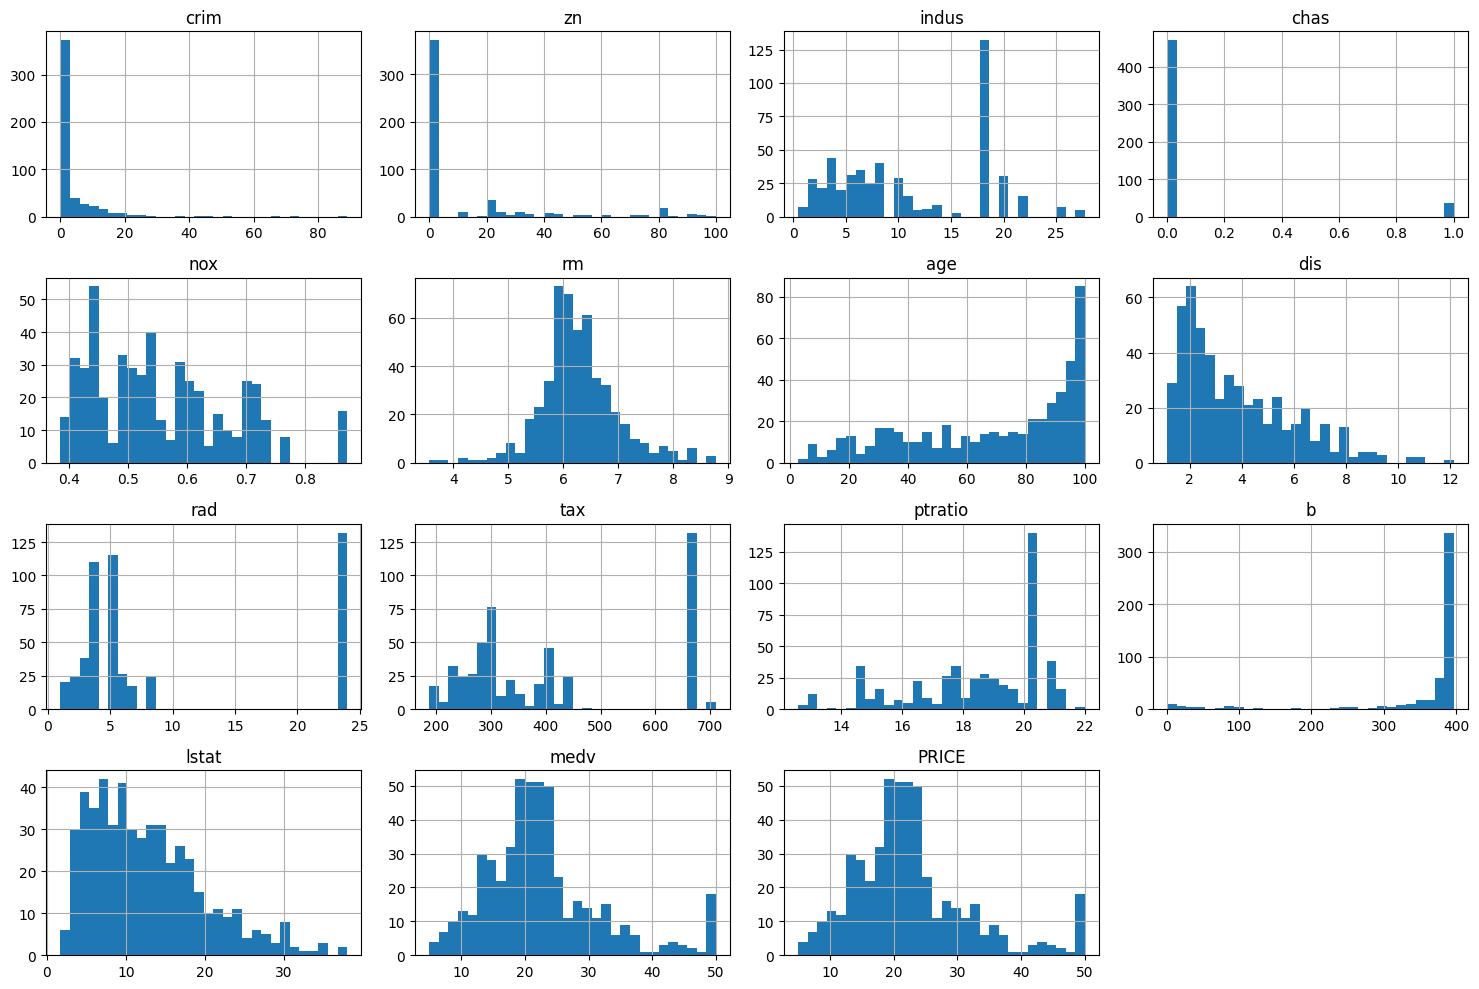

In [74]:
# Histograma de frecuencia para cada columna para visualizar la distribución
df_boston.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

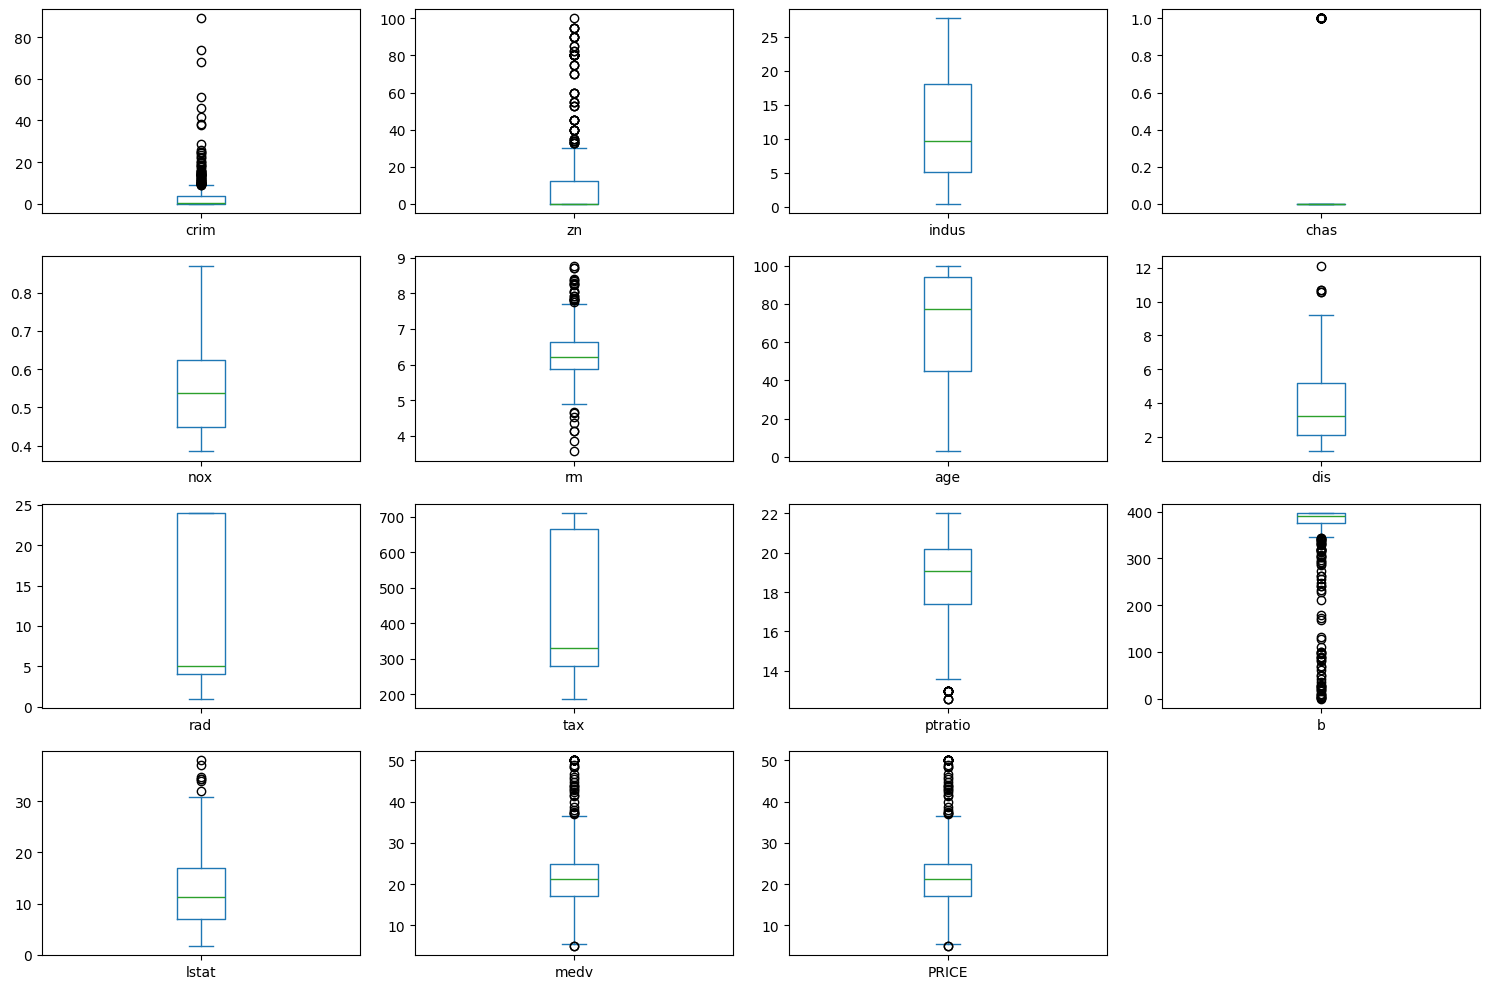

In [75]:
# Diagramas de cajas para detectar posibles outliers
df_boston.plot(kind='box', subplots=True, layout=(4,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

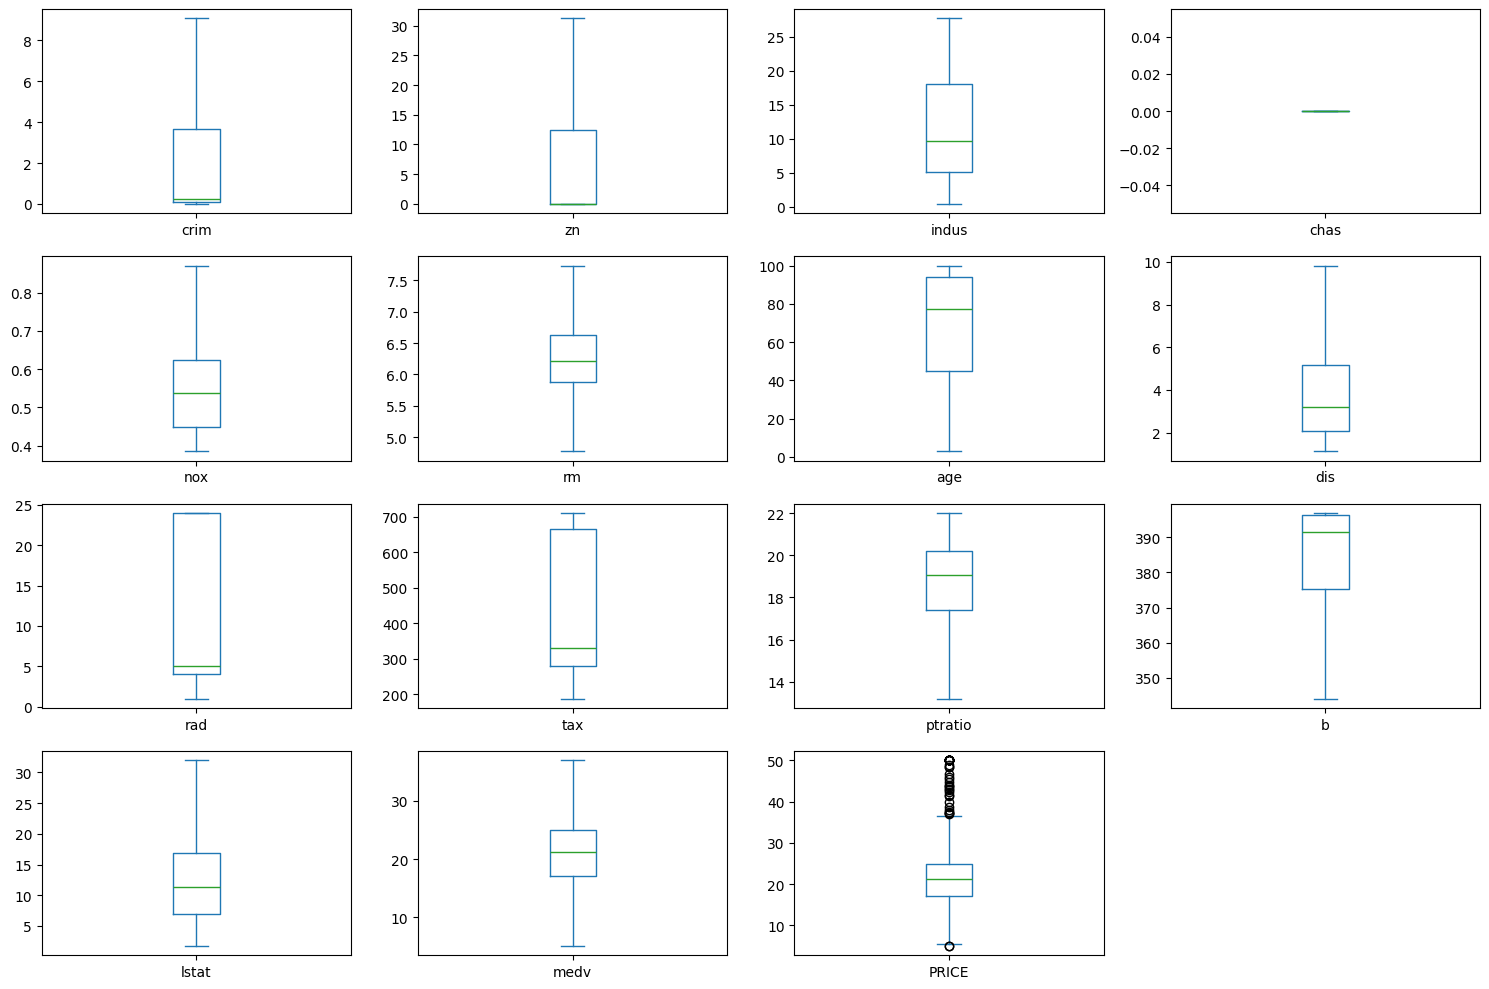

In [76]:
# prompt: genera el codigo para corregir los outliers superiores e inferiores

# Función para corregir outliers usando el método del rango intercuartílico (IQR)
def correct_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)

  # Reemplazar outliers por los límites (opcional: podrías usar la mediana, etc.)
  df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
  df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
  return df

# Aplicar la corrección de outliers a las columnas numéricas (excluyendo PRICE ya que es el objetivo)
for col in df_boston.columns:
  if col != 'PRICE':
    df_boston = correct_outliers_iqr(df_boston, col)

# Mostrar diagramas de cajas después de la corrección para verificar
df_boston.plot(kind='box', subplots=True, layout=(4,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


# 5 - Divir los datos en entrada (Xs) y salida (Y)

In [77]:
# prompt: separa a price como columna 'Y' y reserva el 70% para entrenmiento y 30% para pruneas

from sklearn.model_selection import train_test_split

X = df_boston.drop('PRICE', axis=1)
Y = df_boston['PRICE']


#**6 - Dividir los datos en Entrenamiento (train) en Pruebas (test)**

In [78]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (354, 14)
Shape of X_test: (152, 14)
Shape of Y_train: (354,)
Shape of Y_test: (152,)


#**7 - Crear el Modelo**

Modelo basado en Algoritmo de Arbol de Decisión pararesolver problema de Regresión

In [79]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Árbol de Decisión con profundidad máxima de 5 (poda)
modelo_dt = DecisionTreeRegressor(max_depth=5)

#**8 - Entrenar el Modelo Arbol de Decisión (Decision TREE)**

In [80]:

modelo_dt.fit(X_train, Y_train)



,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

#**9 - Predicción del Modelo**

In [81]:
# Predicción
Y_pred_dt = modelo_dt.predict(X_test)

#**10 - Validacion de Calidad del modelo**

In [82]:
# Evaluación
mse_dt = mean_squared_error(Y_test, Y_pred_dt)
r2_dt = r2_score(Y_test, Y_pred_dt)

print(f'MSE Árbol de Decisión (poda a 5 niveles): {mse_dt}')
print(f'R² Árbol de Decisión (poda a 5 niveles): {r2_dt}')


MSE Árbol de Decisión (poda a 5 niveles): 1.7876321622215414
R² Árbol de Decisión (poda a 5 niveles): 0.9760091545170962


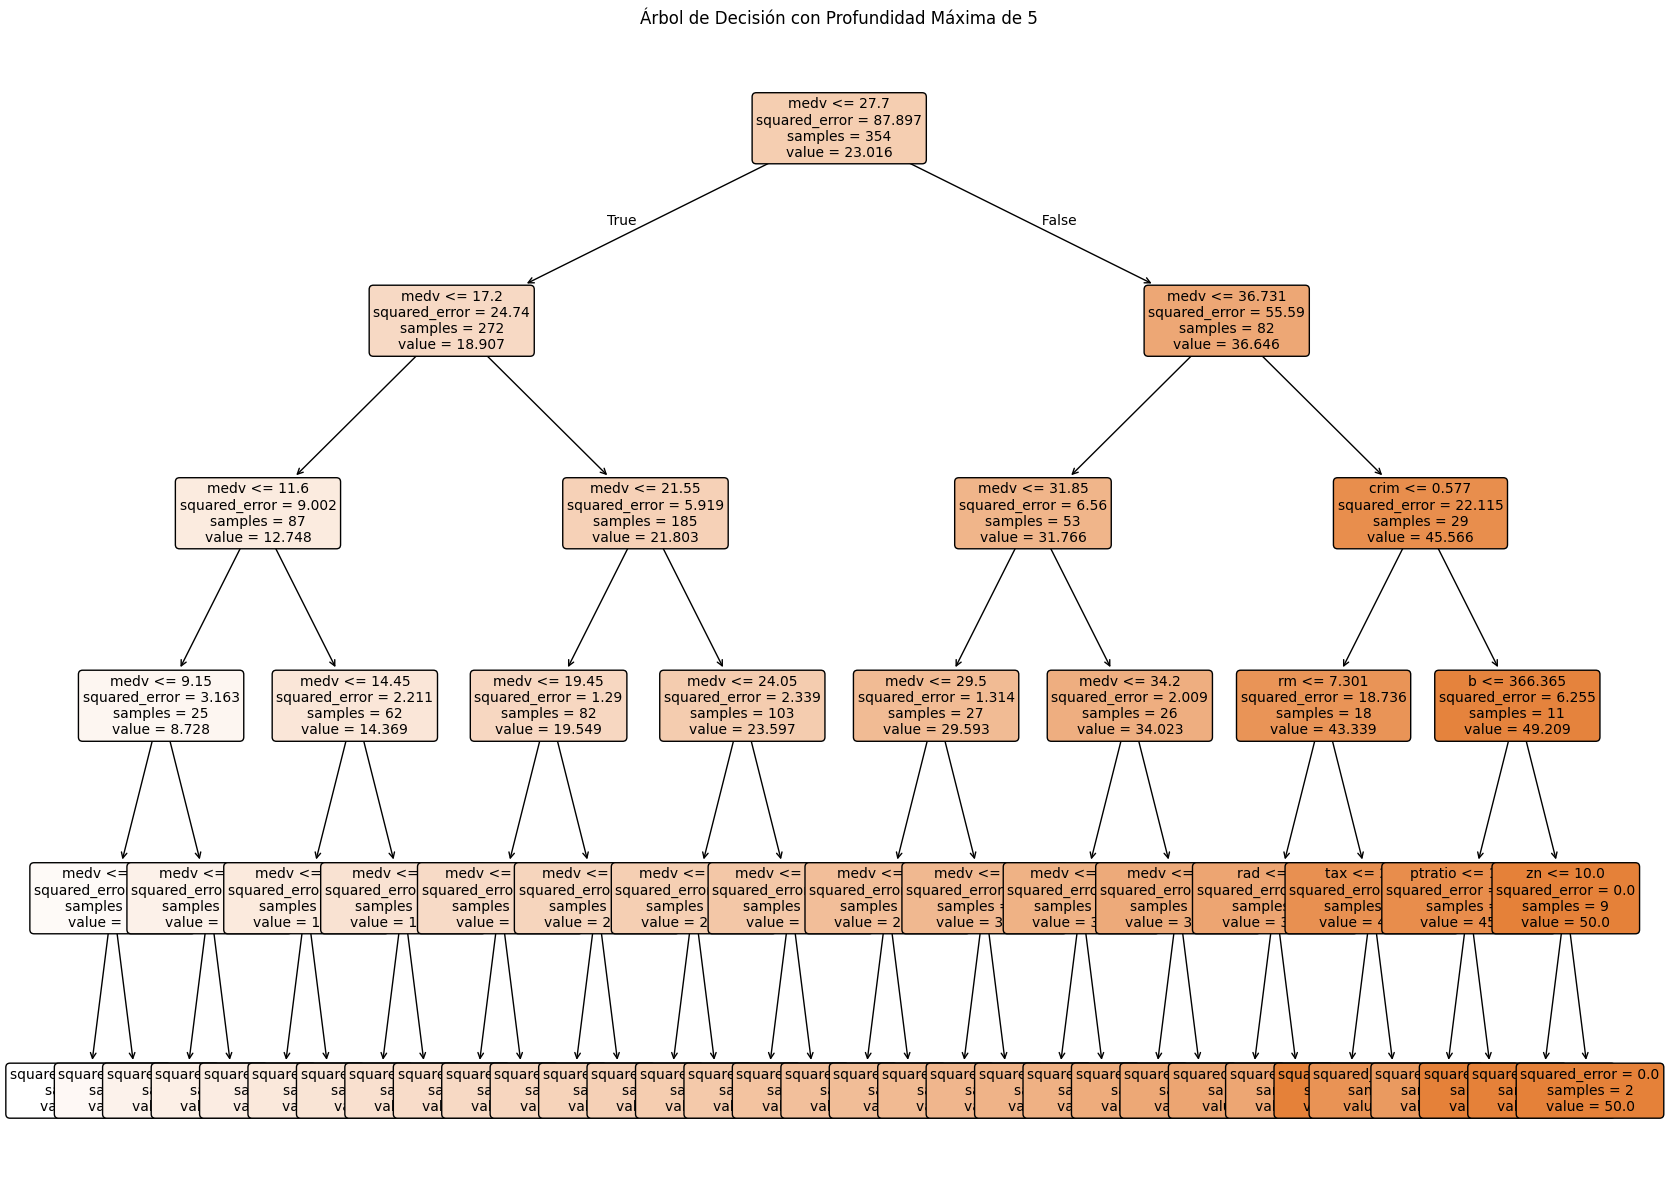

In [83]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plot_tree(modelo_dt,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión con Profundidad Máxima de 5')
plt.show()

#**11 - Arbol a 6 niveles de profundidad**

In [84]:
# Árbol de Decisión con profundidad máxima de 6 (poda)
modelo_dt_v6n = DecisionTreeRegressor(max_depth=6)

In [85]:
# Entrenamiento
modelo_dt_v6n.fit(X_train, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [86]:
# Predicción
Y_pred_dt_v6n = modelo_dt_v6n.predict(X_test)

In [87]:
# Evaluación
mse_dt_v6n = mean_squared_error(Y_test, Y_pred_dt_v6n)
r2_dt_v6n = r2_score(Y_test, Y_pred_dt_v6n)

print(f'MSE Árbol de Decisión (poda a 6 niveles): {mse_dt_v6n}')
print(f'R² Árbol de Decisión (poda a 6 niveles): {r2_dt_v6n}')

MSE Árbol de Decisión (poda a 6 niveles): 2.7941691183181936
R² Árbol de Decisión (poda a 6 niveles): 0.9625009658097852


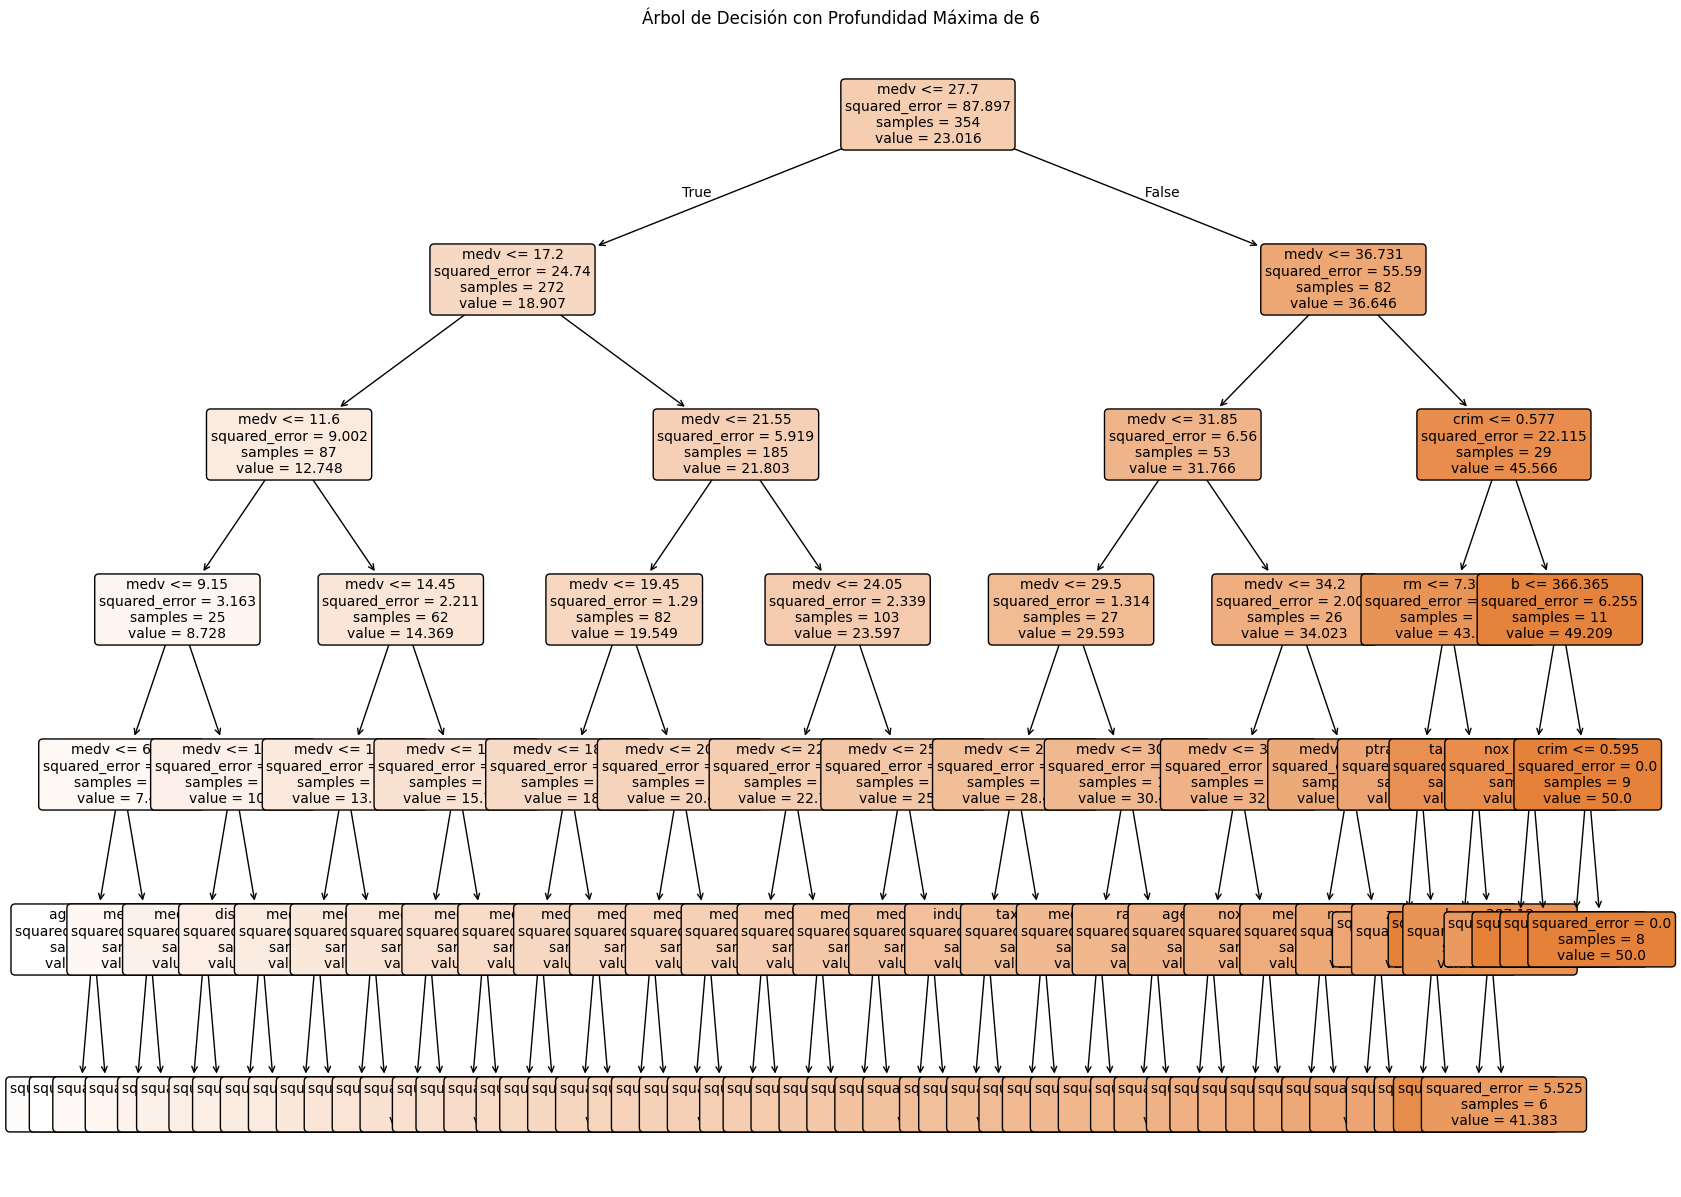

In [88]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plot_tree(modelo_dt_v6n,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión con Profundidad Máxima de 6')
plt.show()

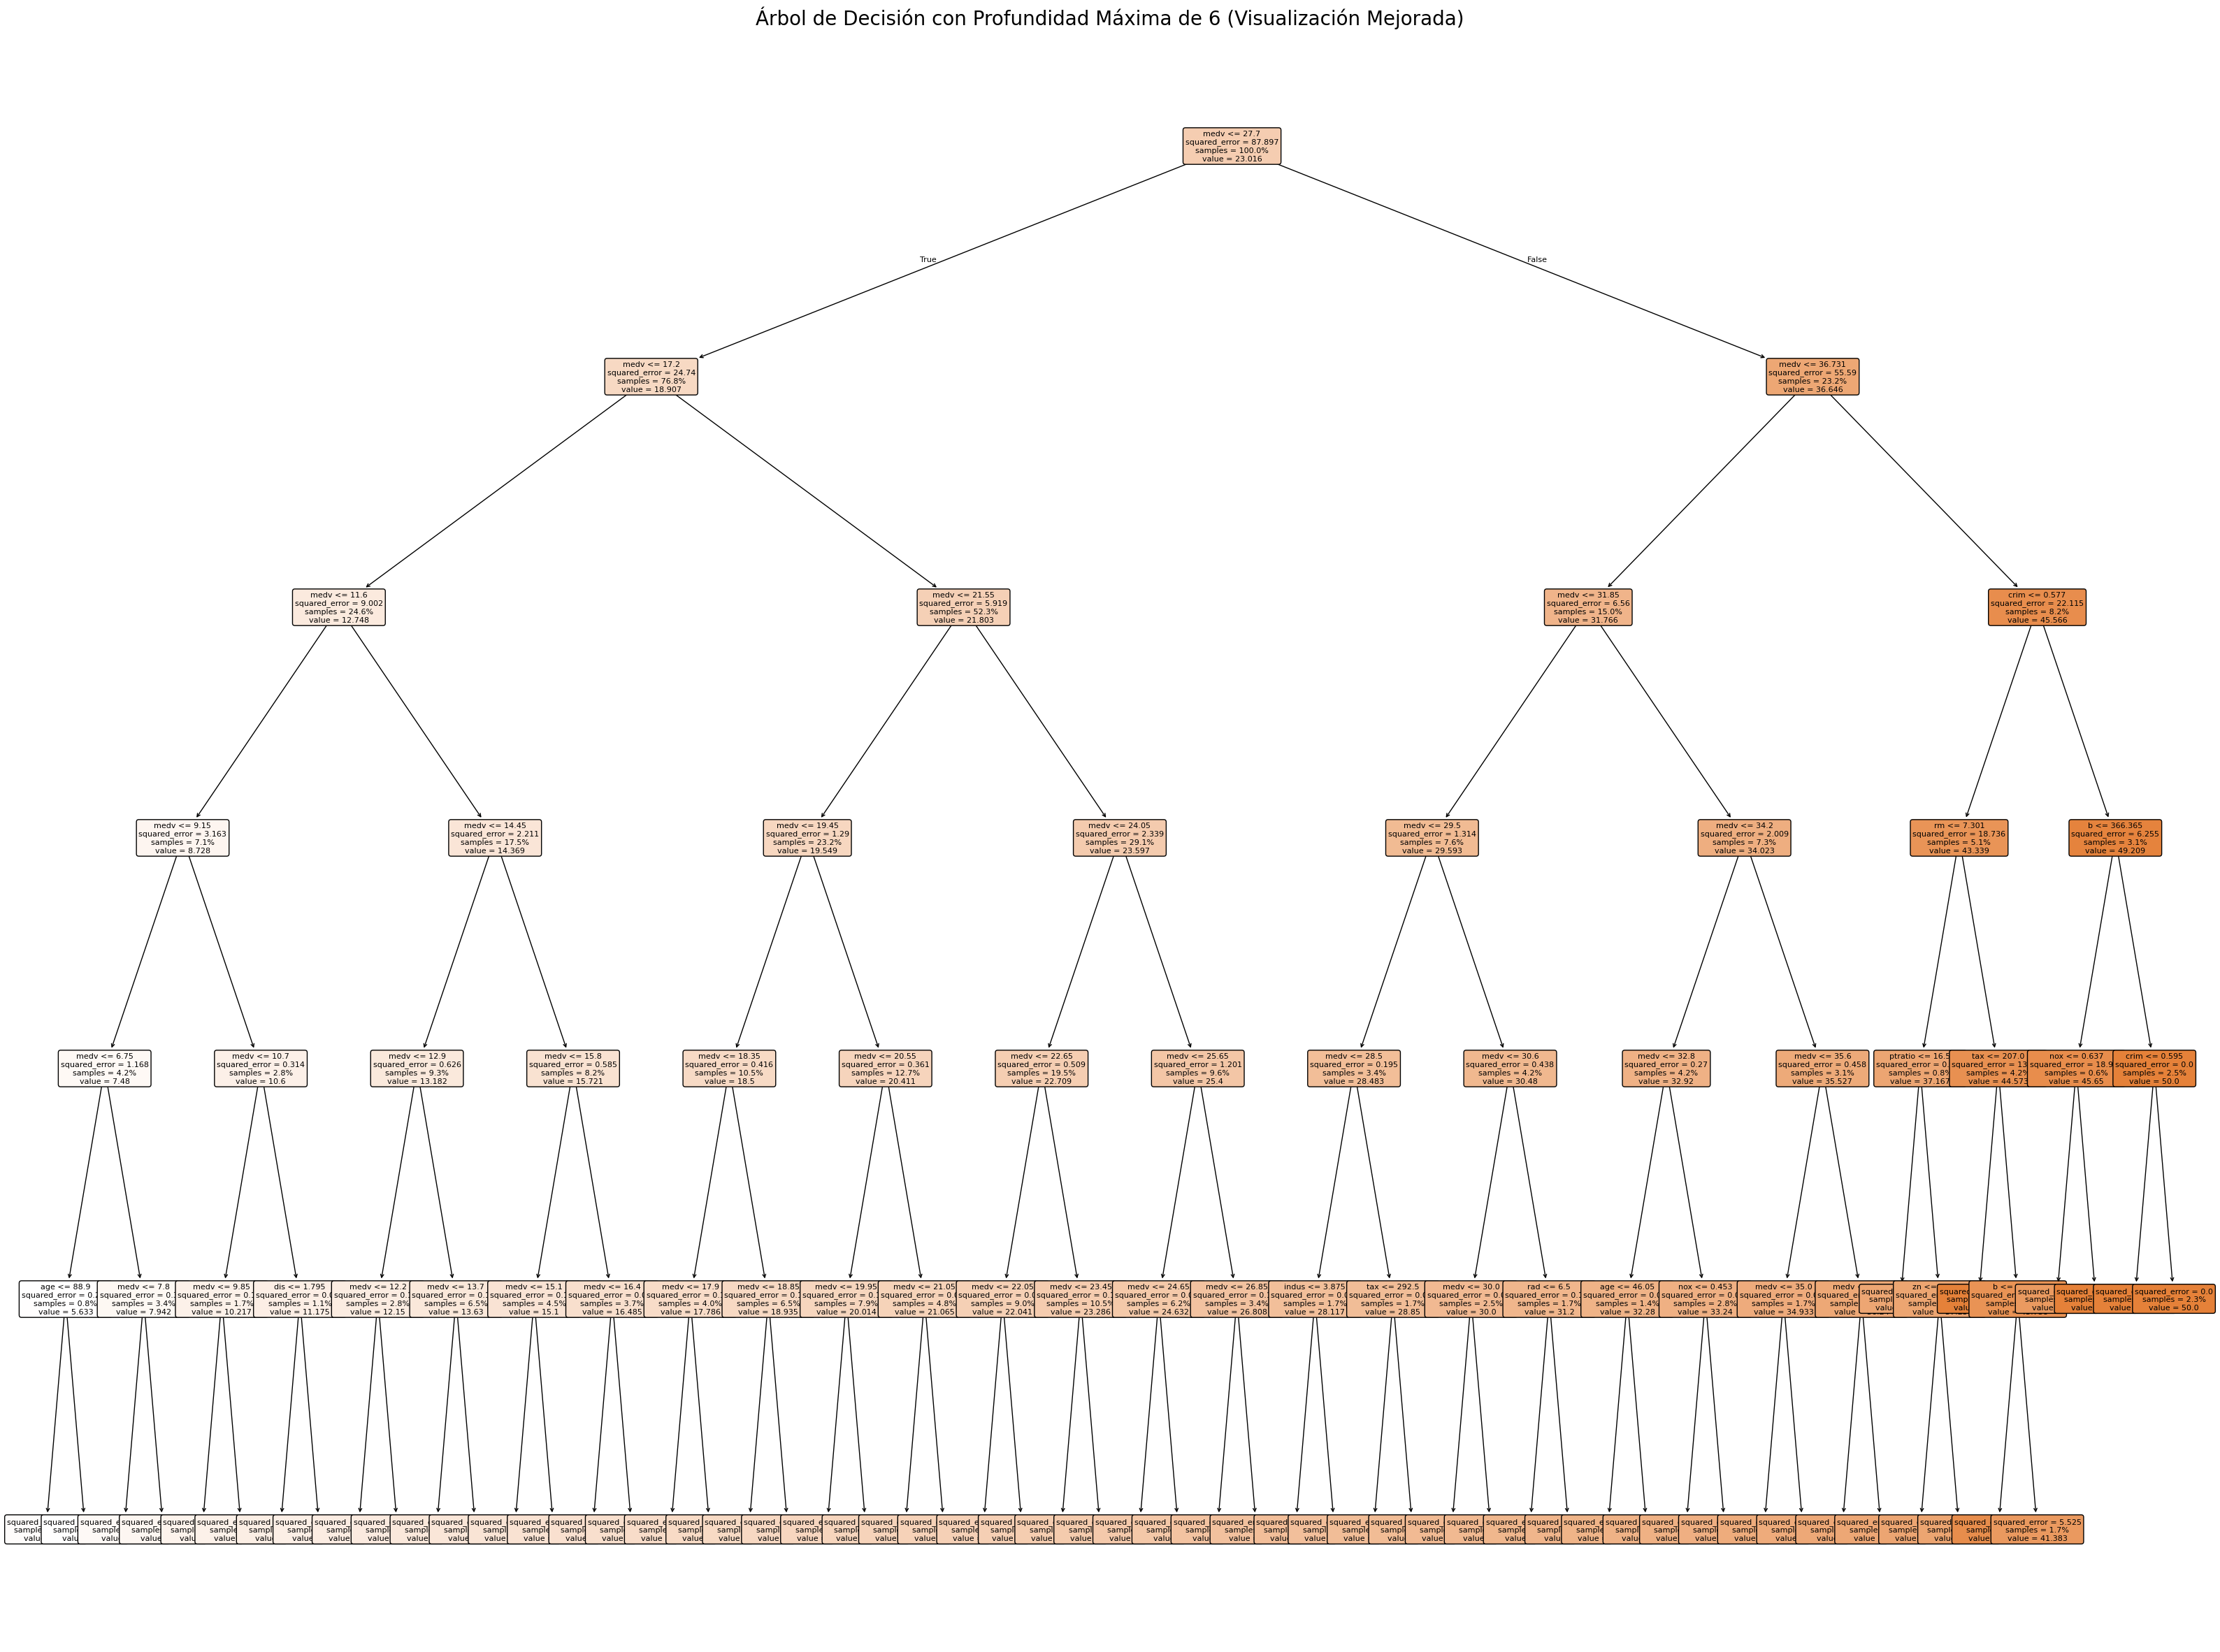

In [89]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,30)) # Increased figure size significantly
plot_tree(modelo_dt_v6n,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=8, # Adjusted fontsize to fit in larger figure
          proportion=True # Proportionally adjust node size
         )
plt.title('Árbol de Decisión con Profundidad Máxima de 6 (Visualización Mejorada)', fontsize=20)
plt.show()

#**11 - Arbol a 7 niveles de profundidad**

In [90]:
# Árbol de Decisión con profundidad máxima de 6 (poda)
modelo_dt_v7n = DecisionTreeRegressor(max_depth=7)

In [91]:
# Entrenamiento
modelo_dt_v7n.fit(X_train, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [92]:
# Predicción
Y_pred_dt_v7n = modelo_dt_v7n.predict(X_test)

In [93]:
# Evaluación
mse_dt_v7n = mean_squared_error(Y_test, Y_pred_dt_v7n)
r2_dt_v7n = r2_score(Y_test, Y_pred_dt_v7n)

print(f'MSE Árbol de Decisión (poda a 7 niveles): {mse_dt_v7n}')
print(f'R² Árbol de Decisión (poda a 7 niveles): {r2_dt_v7n}')

MSE Árbol de Decisión (poda a 7 niveles): 1.9636904330241676
R² Árbol de Decisión (poda a 7 niveles): 0.9736463715799376


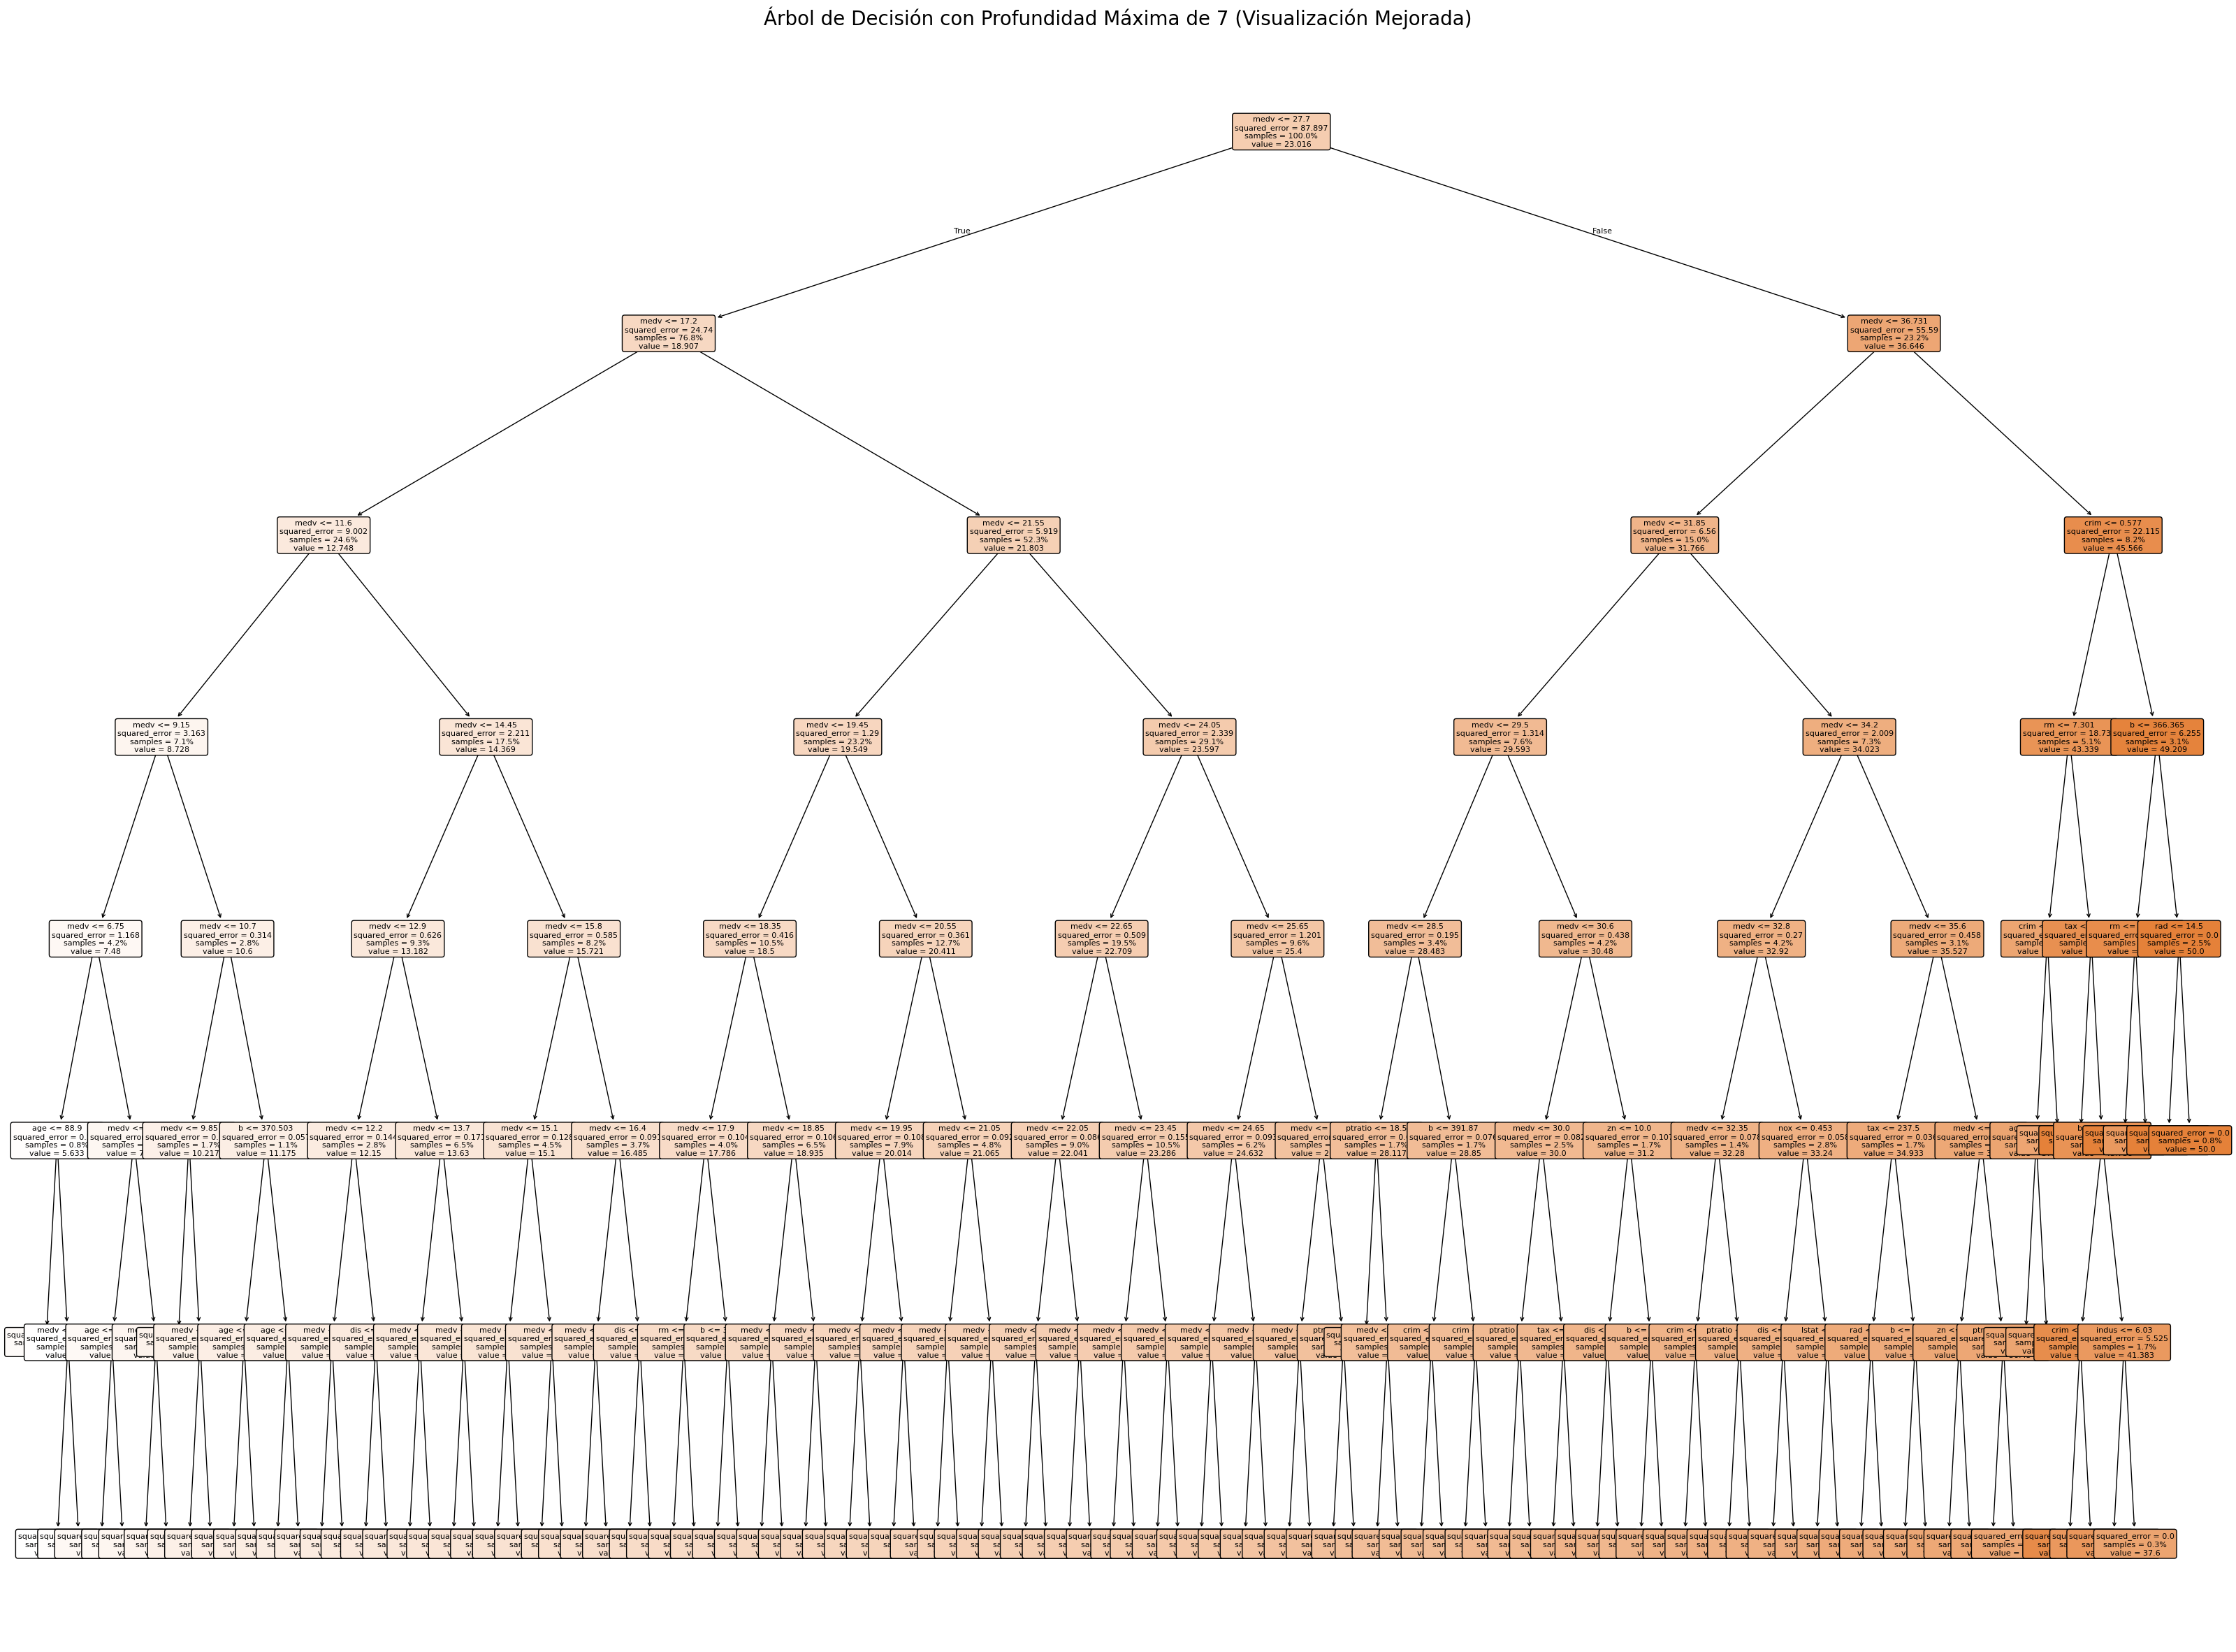

In [94]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,30)) # Increased figure size significantly
plot_tree(modelo_dt_v7n,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=8, # Adjusted fontsize to fit in larger figure
          proportion=True # Proportionally adjust node size
         )
plt.title('Árbol de Decisión con Profundidad Máxima de 7 (Visualización Mejorada)', fontsize=20)
plt.show()

In [95]:
from sklearn.ensemble import RandomForestRegressor

# 12 - Crear, Entrenar y Evaluar el Modelo Random Forest

# Crear el modelo Random Forest con 100 estimadores (bosquesitos)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar el modelo
modelo_rf.fit(X_train, Y_train)

# Predicción
Y_pred_rf = modelo_rf.predict(X_test)

# Evaluación
mse_rf = mean_squared_error(Y_test, Y_pred_rf)
r2_rf = r2_score(Y_test, Y_pred_rf)

print(f'MSE Random Forest (100 estimadores): {mse_rf}')
print(f'R² Random Forest (100 estimadores): {r2_rf}')

MSE Random Forest (100 estimadores): 0.9701713947368361
R² Random Forest (100 estimadores): 0.9869798538452452


In [96]:
from sklearn.ensemble import GradientBoostingRegressor

# Crear el modelo Gradient Boosting
modelo_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
modelo_gb.fit(X_train, Y_train)

# Predicción
Y_pred_gb = modelo_gb.predict(X_test)

# Evaluación
mse_gb = mean_squared_error(Y_test, Y_pred_gb)
r2_gb = r2_score(Y_test, Y_pred_gb)

print(f'MSE Gradient Boosting: {mse_gb}')
print(f'R² Gradient Boosting: {r2_gb}')

MSE Gradient Boosting: 1.1780267175495056
R² Gradient Boosting: 0.9841903398513816


In [97]:
%pip install xgboost

import xgboost as xgb

# Crear el modelo XGBoost
modelo_xgb = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
modelo_xgb.fit(X_train, Y_train)

# Predicción
Y_pred_xgb = modelo_xgb.predict(X_test)

# Evaluación
mse_xgb = mean_squared_error(Y_test, Y_pred_xgb)
r2_xgb = r2_score(Y_test, Y_pred_xgb)

print(f'MSE XGBoost: {mse_xgb}')
print(f'R² XGBoost: {r2_xgb}')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


MSE XGBoost: 0.8538091404578776
R² XGBoost: 0.9885414887953458


In [98]:
# 15 - Modelo LightGBM
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# Crear el modelo LightGBM
modelo_lgb = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
modelo_lgb.fit(X_train, Y_train)

# Predicción
Y_pred_lgb = modelo_lgb.predict(X_test)

# Evaluación
mse_lgb = mean_squared_error(Y_test, Y_pred_lgb)
r2_lgb = r2_score(Y_test, Y_pred_lgb)

print(f'MSE LightGBM: {mse_lgb}')
print(f'R² LightGBM: {r2_lgb}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 960
[LightGBM] [Info] Number of data points in the train set: 354, number of used features: 13
[LightGBM] [Info] Start training from score 23.015819
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [100]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np


def registrar_metricas(nombre_modelo, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "Modelo": nombre_modelo,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }


resultados = []

# Registrar solo si la prediccion existe (evita errores si falta ejecutar alguna celda)
if "Y_pred_dt" in globals():
    resultados.append(registrar_metricas("Decision Tree (max_depth=5)", Y_test, Y_pred_dt))

if "Y_pred_dt_v6n" in globals():
    resultados.append(registrar_metricas("Decision Tree (max_depth=6)", Y_test, Y_pred_dt_v6n))

if "Y_pred_dt_v7n" in globals():
    resultados.append(registrar_metricas("Decision Tree (max_depth=7)", Y_test, Y_pred_dt_v7n))

if "Y_pred_rf" in globals():
    resultados.append(registrar_metricas("Random Forest", Y_test, Y_pred_rf))

if "Y_pred_gb" in globals():
    resultados.append(registrar_metricas("Gradient Boosting", Y_test, Y_pred_gb))

if "Y_pred_xgb" in globals():
    resultados.append(registrar_metricas("XGBoost", Y_test, Y_pred_xgb))

if "Y_pred_lgb" in globals():
    resultados.append(registrar_metricas("LightGBM", Y_test, Y_pred_lgb))


df_resultados = pd.DataFrame(resultados)

if len(df_resultados) > 0:
    # Orden de mejor a peor: mayor R2 y menor RMSE
    df_resultados = (
        df_resultados.sort_values(by=["R2", "RMSE"], ascending=[False, True])
        .reset_index(drop=True)
    )

    print("Tabla comparativa de modelos:")
    display(df_resultados.round({"MSE": 4, "RMSE": 4, "MAE": 4, "R2": 4}))

    mejor = df_resultados.iloc[0]
    print(
        f"\nConclusion:\n"
        f"El modelo mas adecuado para estos datos es {mejor['Modelo']}, "
        f"porque obtuvo el mayor R2 ({mejor['R2']:.4f}) y un RMSE de {mejor['RMSE']:.4f}."
    )
else:
    print("No hay resultados para comparar. Ejecuta primero las celdas de entrenamiento y prediccion.")

Tabla comparativa de modelos:


,Modelo,MSE,RMSE,MAE,R2
0,XGBoost,0.8538,0.9240,0.3270,0.9885
1,Random Forest,0.9702,0.9850,0.2806,0.9870
2,Gradient Boosting,1.1780,1.0854,0.3432,0.9842
3,LightGBM,1.3626,1.1673,0.5973,0.9817
4,Decision Tree (max_depth=5),1.7876,1.3370,0.5724,0.9760
5,Decision Tree (max_depth=7),1.9637,1.4013,0.3898,0.9736
6,Decision Tree (max_depth=6),2.7942,1.6716,0.5299,0.9625



Conclusion:
El modelo mas adecuado para estos datos es XGBoost, porque obtuvo el mayor R2 (0.9885) y un RMSE de 0.9240.
